In [1]:
from __future__ import annotations

from copy import deepcopy
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.patches import Patch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, precision_recall_fscore_support
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from scripts.covfee_baseline_utils import (
    BACKGROUND_LABEL,
    CANONICAL_LABEL_ORDER,
    CHANNEL_COLUMNS,
    SPLIT_CONFIGS,
    TARGET_COLUMN,
    build_annotation_splits,
    build_grouped_windows,
    evaluate_split,
    evaluate_timeline_diagnostics,
    filter_windows,
    label_order_from_values,
    load_covfee_manual_data,
    standardize_from_train,
    summarize_splits,
)


In [2]:
COVFEE_OUTPUT_DIR = Path("outputs") / "covfee"
WINDOW_SECONDS = 1.0
STRIDE_SECONDS = 1.0
TARGET_FS = None
MIN_LABEL_PURITY = 0.0
DROP_STILL_WINDOWS = False

BATCH_SIZE = 64
MAX_EPOCHS = 50
PATIENCE = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
RANDOM_SEED = 42

SPLIT_CONFIGS


{'split_A_eval_01_v1': {'eval_annotations': ['01_v1', '20_v2', '27_v2']},
 'split_B_eval_24_v1': {'eval_annotations': ['24_v1', '18_v2', '27_v2']}}

In [3]:
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [4]:
df, preprocessing_summary, DATA_PATH = load_covfee_manual_data(Path.cwd(), COVFEE_OUTPUT_DIR)

print(f"Rows: {len(df):,}")
print(f"Annotations: {df['annotation_id'].nunique()}")
display(preprocessing_summary[["annotation_id", "status", "video_start", "video_end", "rows", "windows"]])
display(df.head())
display(df[TARGET_COLUMN].value_counts().rename("sample_count").to_frame())
DATA_PATH


Rows: 150,000
Annotations: 10


,annotation_id,status,video_start,video_end,rows,windows
0,01_v1,ok,2025-07-17 14:02:30.166833333,2025-07-17 14:07:30.166833333,15000,150
1,03_v1,ok,2025-07-17 14:02:30.166833333,2025-07-17 14:07:30.166833333,15000,150
2,03_v2,ok,2025-07-17 15:20:32.116783333,2025-07-17 15:25:32.116783333,15000,150
3,16_v1,ok,2025-07-17 14:02:30.166833333,2025-07-17 14:07:30.166833333,15000,150
4,16_v2,ok,2025-07-17 15:20:32.116783333,2025-07-17 15:25:32.116783333,15000,150
5,17_v1,ok,2025-07-17 14:02:30.166833333,2025-07-17 14:07:30.166833333,15000,150
6,18_v2,ok,2025-07-17 15:20:32.116783333,2025-07-17 15:25:32.116783333,15000,150
7,20_v2,ok,2025-07-17 15:20:32.116783333,2025-07-17 15:25:32.116783333,15000,150
8,24_v1,ok,2025-07-17 14:02:30.166833333,2025-07-17 14:07:30.166833333,15000,150
9,27_v2,ok,2025-07-17 15:20:32.116783333,2025-07-17 15:25:32.116783333,15000,150


,time,x,y,z,state,manual_label,video_name,participant_no,participant_id,annotation_id,alignment_mode,preprocessed_at
0,2025-07-17 14:02:30.180,-0.197876,-0.151733,-0.875854,0,Still,v1,1,81,01_v1,hardcoded_source_clip_offset,2026-05-05 11:45:52
1,2025-07-17 14:02:30.200,-0.194946,-0.140503,-0.872925,0,Still,v1,1,81,01_v1,hardcoded_source_clip_offset,2026-05-05 11:45:52
2,2025-07-17 14:02:30.220,-0.158813,-0.128296,-0.875366,0,Still,v1,1,81,01_v1,hardcoded_source_clip_offset,2026-05-05 11:45:52
3,2025-07-17 14:02:30.240,-0.170044,-0.129272,-0.915894,0,Still,v1,1,81,01_v1,hardcoded_source_clip_offset,2026-05-05 11:45:52
4,2025-07-17 14:02:30.260,-0.178345,-0.126831,-0.951050,0,Still,v1,1,81,01_v1,hardcoded_source_clip_offset,2026-05-05 11:45:52


,sample_count
manual_label,
Still,110061
Gesture,26953
Nodding,11833
Drinking,987
Toasting,166


WindowsPath('outputs/covfee/covfee_manual_labels_combined.csv')

In [5]:
X_all, y_all, meta_all, sampling_summary, window_size, stride_size = build_grouped_windows(
    df,
    channel_columns=CHANNEL_COLUMNS,
    target_column=TARGET_COLUMN,
    target_fs=TARGET_FS,
    window_seconds=WINDOW_SECONDS,
    stride_seconds=STRIDE_SECONDS,
)

X, y, meta, filter_diagnostics = filter_windows(
    X_all,
    y_all,
    meta_all,
    min_label_purity=MIN_LABEL_PURITY,
    background_label=BACKGROUND_LABEL,
    drop_still_windows=DROP_STILL_WINDOWS,
)
label_order = label_order_from_values(y)
class_names = label_order
class_to_idx = {label: idx for idx, label in enumerate(class_names)}
idx_to_class = np.asarray(class_names)
n_classes = len(class_names)

print(f"Median effective sampling rate: {sampling_summary['estimated_fs'].median():.2f} Hz")
print(f"Window size: {window_size} samples")
print(f"Stride size: {stride_size} samples")
print(f"Window tensor shape: {X.shape}  # (n_windows, n_channels, window_length)")
print(f"Drop Still/background windows: {DROP_STILL_WINDOWS}")
print(f"Removed by purity filter: {filter_diagnostics['n_removed_by_purity']:,}")
print(f"Removed Still/background windows: {filter_diagnostics['n_removed_background']:,}")
display(sampling_summary)
display(meta.head())
display(pd.Series(y).value_counts().reindex(label_order, fill_value=0).rename("window_count").to_frame())


Median effective sampling rate: 50.00 Hz
Window size: 50 samples
Stride size: 50 samples
Window tensor shape: (3000, 3, 50)  # (n_windows, n_channels, window_length)
Drop Still/background windows: False
Removed by purity filter: 0
Removed Still/background windows: 0


,annotation_id,estimated_fs,rows
0,01_v1,50.0,15000
1,03_v1,50.0,15000
2,03_v2,50.0,15000
3,16_v1,50.0,15000
4,16_v2,50.0,15000
5,17_v1,50.0,15000
6,18_v2,50.0,15000
7,20_v2,50.0,15000
8,24_v1,50.0,15000
9,27_v2,50.0,15000


,start_idx,end_idx,start_time,end_time,label,purity,n_unique_labels,annotation_id,participant_no,participant_id,video_name,alignment_mode,estimated_fs
0,0,50,2025-07-17 14:02:30.180,2025-07-17 14:02:31.160,Gesture,0.7,2,01_v1,1,81,v1,hardcoded_source_clip_offset,50.0
1,50,100,2025-07-17 14:02:31.180,2025-07-17 14:02:32.160,Gesture,1.0,1,01_v1,1,81,v1,hardcoded_source_clip_offset,50.0
2,100,150,2025-07-17 14:02:32.180,2025-07-17 14:02:33.160,Gesture,1.0,1,01_v1,1,81,v1,hardcoded_source_clip_offset,50.0
3,150,200,2025-07-17 14:02:33.180,2025-07-17 14:02:34.160,Gesture,1.0,1,01_v1,1,81,v1,hardcoded_source_clip_offset,50.0
4,200,250,2025-07-17 14:02:34.180,2025-07-17 14:02:35.160,Gesture,1.0,1,01_v1,1,81,v1,hardcoded_source_clip_offset,50.0


,window_count
Still,2204
Gesture,544
Nodding,228
Drinking,20
Toasting,4


In [6]:
purity_summary = pd.DataFrame(
    {
        "metric": [
            "n_windows",
            "mean_purity",
            "median_purity",
            "pure_windows_ratio",
            "mixed_windows_ratio",
            "purity_ge_0.9_ratio",
            "purity_ge_0.8_ratio",
        ],
        "value": [
            len(meta),
            meta["purity"].mean(),
            meta["purity"].median(),
            (meta["purity"] == 1.0).mean(),
            (meta["purity"] < 1.0).mean(),
            (meta["purity"] >= 0.9).mean(),
            (meta["purity"] >= 0.8).mean(),
        ],
    }
)
display(purity_summary)
display(meta[["purity", "n_unique_labels"]].describe())


,metric,value
0,n_windows,3000.000000
1,mean_purity,0.932167
2,median_purity,1.000000
3,pure_windows_ratio,0.756333
4,mixed_windows_ratio,0.243667
5,purity_ge_0.9_ratio,0.791667
6,purity_ge_0.8_ratio,0.841000


,purity,n_unique_labels
count,3000.000000,3000.00000
mean,0.932167,1.24900
std,0.137840,0.44467
min,0.360000,1.00000
25%,1.000000,1.00000
50%,1.000000,1.00000
75%,1.000000,1.00000
max,1.000000,3.00000


In [7]:
raw_splits = build_annotation_splits(X, y, meta, SPLIT_CONFIGS)
split_summary, label_counts_df, annotation_split_df = summarize_splits(raw_splits, label_order)

display(split_summary)
display(label_counts_df)
display(annotation_split_df)


,split_config,subset,n_windows,annotations,start,end
0,split_A_eval_01_v1,train,2100,7,2025-07-17 14:02:30.180,2025-07-17 15:25:32.100
1,split_A_eval_01_v1,eval,900,3,2025-07-17 14:02:30.180,2025-07-17 15:25:32.100
2,split_B_eval_24_v1,train,2100,7,2025-07-17 14:02:30.180,2025-07-17 15:25:32.100
3,split_B_eval_24_v1,eval,900,3,2025-07-17 14:02:30.180,2025-07-17 15:25:32.100


subset                       eval  train
split_config       label                
split_A_eval_01_v1 Drinking     5     15
                   Gesture    163    381
                   Nodding     96    132
                   Still      634   1570
                   Toasting     2      2
split_B_eval_24_v1 Drinking     4     16
                   Gesture    194    350
                   Nodding     93    135
                   Still      607   1597
                   Toasting     2      2

subset                            eval  train
split_config       annotation_id             
split_A_eval_01_v1 01_v1           300      0
                   03_v1             0    300
                   03_v2             0    300
                   16_v1             0    300
                   16_v2             0    300
                   17_v1             0    300
                   18_v2             0    300
                   20_v2           300      0
                   24_v1             0    300
                   27_v2           300      0
split_B_eval_24_v1 01_v1             0    300
                   03_v1             0    300
                   03_v2             0    300
                   16_v1             0    300
                   16_v2             0    300
                   17_v1             0    300
                   18_v2           300      0
                   20_v2             0    300
                   24_v1           300      0
                   27_v2           300      0

In [8]:
def encode_labels(labels: np.ndarray) -> np.ndarray:
    return np.asarray([class_to_idx[label] for label in labels], dtype=np.int64)


splits = {}
for split_name, split_data in raw_splits.items():
    X_train, X_eval = standardize_from_train(split_data["x_train"], split_data["x_train"], split_data["x_eval"])
    y_train_encoded = encode_labels(split_data["y_train"])
    y_eval_encoded = encode_labels(split_data["y_eval"])
    splits[split_name] = {
        **split_data,
        "x_train_std": X_train,
        "x_eval_std": X_eval,
        "y_train_encoded": y_train_encoded,
        "y_eval_encoded": y_eval_encoded,
    }

label_order_encoded = np.asarray([class_to_idx[label] for label in label_order], dtype=np.int64)


In [9]:
def make_loader(X_array: np.ndarray, y_array: np.ndarray, *, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(torch.from_numpy(X_array), torch.from_numpy(y_array.astype(np.int64)))
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle)


def decode_labels(encoded: np.ndarray) -> np.ndarray:
    return idx_to_class[np.asarray(encoded, dtype=np.int64)]


In [10]:
class CNN1DClassifier(nn.Module):
    def __init__(self, n_channels: int, n_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class GRUClassifier(nn.Module):
    def __init__(self, n_channels: int, n_classes: int, hidden_size: int = 64):
        super().__init__()
        self.rnn = nn.GRU(input_size=n_channels, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.head = nn.Sequential(nn.Dropout(0.25), nn.Linear(hidden_size, n_classes))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        sequence = x.transpose(1, 2)
        _, hidden = self.rnn(sequence)
        return self.head(hidden[-1])


class DeepConvLSTMClassifier(nn.Module):
    def __init__(self, n_channels: int, n_classes: int, hidden_size: int = 64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Dropout(0.20),
        )
        self.rnn = nn.LSTM(input_size=64, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.head = nn.Sequential(nn.Dropout(0.25), nn.Linear(hidden_size, n_classes))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.conv(x).transpose(1, 2)
        _, (hidden, _) = self.rnn(features)
        return self.head(hidden[-1])


class TCNBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, dilation: int = 1, dropout: float = 0.20):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
        )
        self.residual = nn.Identity() if in_channels == out_channels else nn.Conv1d(in_channels, out_channels, kernel_size=1)
        self.activation = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.activation(self.conv(x) + self.residual(x))


class TCNClassifier(nn.Module):
    def __init__(self, n_channels: int, n_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            TCNBlock(n_channels, 64, dilation=1),
            TCNBlock(64, 64, dilation=2),
            TCNBlock(64, 128, dilation=4),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(128, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.features(x))


n_channels = X.shape[1]
model_builders: dict[str, Callable[[], nn.Module]] = {
    "cnn1d": lambda: CNN1DClassifier(n_channels, n_classes),
    "gru": lambda: GRUClassifier(n_channels, n_classes),
    "deep_conv_lstm": lambda: DeepConvLSTMClassifier(n_channels, n_classes),
    "tcn": lambda: TCNClassifier(n_channels, n_classes),
}
model_builders


{'cnn1d': <function __main__.<lambda>()>,
 'gru': <function __main__.<lambda>()>,
 'deep_conv_lstm': <function __main__.<lambda>()>,
 'tcn': <function __main__.<lambda>()>}

In [11]:
def build_class_weights(y_train_encoded: np.ndarray) -> torch.Tensor:
    class_counts = np.bincount(y_train_encoded, minlength=n_classes)
    class_weights = class_counts.sum() / np.maximum(class_counts, 1)
    class_weights = class_weights / class_weights.mean()
    return torch.tensor(class_weights, dtype=torch.float32, device=device)


pd.DataFrame(
    {
        "label": class_names,
        "example_train_count_split_A": np.bincount(splits["split_A_eval_01_v1"]["y_train_encoded"], minlength=n_classes),
    }
)


,label,example_train_count_split_A
0,Still,1570
1,Gesture,381
2,Nodding,132
3,Drinking,15
4,Toasting,2


In [12]:
def run_epoch(model: nn.Module, loader: DataLoader, criterion: nn.Module, optimizer: torch.optim.Optimizer | None = None) -> float:
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_seen = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)
            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * len(xb)
        total_seen += len(xb)

    return total_loss / max(total_seen, 1)


@torch.no_grad()
def predict(model: nn.Module, loader: DataLoader) -> np.ndarray:
    model.eval()
    preds = []
    for xb, _ in loader:
        logits = model(xb.to(device))
        preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)


def train_model(
    split_name: str,
    model_name: str,
    builder: Callable[[], nn.Module],
    train_loader: DataLoader,
    eval_loader: DataLoader,
    y_eval_encoded: np.ndarray,
    class_weights_tensor: torch.Tensor,
) -> tuple[nn.Module, pd.DataFrame]:
    torch.manual_seed(RANDOM_SEED)
    model = builder().to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    best_state = deepcopy(model.state_dict())
    best_eval_loss = float("inf")
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_epoch(model, train_loader, criterion, optimizer)
        eval_loss = run_epoch(model, eval_loader, criterion)
        eval_pred = predict(model, eval_loader)
        eval_macro_f1 = precision_recall_fscore_support(y_eval_encoded, eval_pred, average="macro", zero_division=0)[2]
        eval_active_f1 = evaluate_split("eval", decode_labels(y_eval_encoded), decode_labels(eval_pred))["active_macro_f1_no_still"]

        history.append(
            {
                "split_config": split_name,
                "model": model_name,
                "epoch": epoch,
                "train_loss": train_loss,
                "eval_loss": eval_loss,
                "eval_macro_f1": eval_macro_f1,
                "eval_active_macro_f1_no_still": eval_active_f1,
            }
        )

        if eval_loss < best_eval_loss - 1e-4:
            best_eval_loss = eval_loss
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


In [13]:
trained_models = {}
histories = []
predictions = {}
eval_prediction_tables = {}
reports = {}
results = []
timeline_diagnostics = []

for split_name, split_data in splits.items():
    train_loader = make_loader(split_data["x_train_std"], split_data["y_train_encoded"], shuffle=True)
    eval_loader = make_loader(split_data["x_eval_std"], split_data["y_eval_encoded"], shuffle=False)
    class_weights_tensor = build_class_weights(split_data["y_train_encoded"])

    trained_models[split_name] = {}
    predictions[split_name] = {}
    reports[split_name] = {}
    eval_prediction_tables[split_name] = {}

    for model_name, builder in model_builders.items():
        print(f"Training {split_name} / {model_name}...")
        model, history = train_model(
            split_name,
            model_name,
            builder,
            train_loader,
            eval_loader,
            split_data["y_eval_encoded"],
            class_weights_tensor,
        )
        trained_models[split_name][model_name] = model
        histories.append(history)

        train_pred_encoded = predict(model, train_loader)
        eval_pred_encoded = predict(model, eval_loader)
        train_pred = decode_labels(train_pred_encoded)
        eval_pred = decode_labels(eval_pred_encoded)
        y_train = split_data["y_train"]
        y_eval = split_data["y_eval"]

        predictions[split_name][model_name] = {
            "train_encoded": train_pred_encoded,
            "eval_encoded": eval_pred_encoded,
            "train": train_pred,
            "eval": eval_pred,
        }
        reports[split_name][model_name] = classification_report(
            y_eval,
            eval_pred,
            labels=label_order,
            zero_division=0,
        )
        eval_prediction_tables[split_name][model_name] = split_data["eval_meta"][["annotation_id", "start_time", "end_time", "purity"]].assign(
            y_true=y_eval,
            y_pred=eval_pred,
        )
        results.extend(
            [
                {"split_config": split_name, "model": model_name, **evaluate_split("train", y_train, train_pred)},
                {"split_config": split_name, "model": model_name, **evaluate_split("eval", y_eval, eval_pred)},
            ]
        )
        timeline_diagnostics.extend(
            [
                {"split_config": split_name, "model": model_name, **evaluate_timeline_diagnostics("train", y_train, train_pred)},
                {"split_config": split_name, "model": model_name, **evaluate_timeline_diagnostics("eval", y_eval, eval_pred)},
            ]
        )

history_df = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
results_df = pd.DataFrame(results)
timeline_diagnostics_df = pd.DataFrame(timeline_diagnostics)

display(results_df)
display(timeline_diagnostics_df)


Training split_A_eval_01_v1 / cnn1d...
Training split_A_eval_01_v1 / gru...
Training split_A_eval_01_v1 / deep_conv_lstm...
Training split_A_eval_01_v1 / tcn...
Training split_B_eval_24_v1 / cnn1d...
Training split_B_eval_24_v1 / gru...
Training split_B_eval_24_v1 / deep_conv_lstm...
Training split_B_eval_24_v1 / tcn...


,split_config,model,split,accuracy,macro_precision,macro_recall,macro_f1,active_accuracy,active_macro_precision_no_still,active_macro_recall_no_still,active_macro_f1_no_still,n_samples,active_n_samples
0,split_A_eval_01_v1,cnn1d,train,0.314762,0.198082,0.184818,0.154344,0.266038,0.236984,0.148219,0.161361,2100,530
1,split_A_eval_01_v1,cnn1d,eval,0.527778,0.270765,0.393465,0.280049,0.255639,0.430678,0.331343,0.342770,900,266
2,split_A_eval_01_v1,gru,train,0.194762,0.194538,0.201982,0.118506,0.288679,0.277246,0.211713,0.181744,2100,530
3,split_A_eval_01_v1,gru,eval,0.270000,0.277231,0.363233,0.214808,0.323308,0.476362,0.392133,0.369173,900,266
4,split_A_eval_01_v1,deep_conv_lstm,train,0.324762,0.196520,0.186488,0.155213,0.247170,0.230894,0.145371,0.154526,2100,530
5,split_A_eval_01_v1,deep_conv_lstm,eval,0.486667,0.257862,0.378644,0.258249,0.274436,0.313942,0.329378,0.254257,900,266
6,split_A_eval_01_v1,tcn,train,0.428571,0.192744,0.175026,0.174875,0.220755,0.226882,0.094100,0.132392,2100,530
7,split_A_eval_01_v1,tcn,eval,0.608889,0.299268,0.451384,0.288751,0.236842,0.532620,0.372984,0.315765,900,266
8,split_B_eval_24_v1,cnn1d,train,0.441905,0.195564,0.190423,0.177730,0.196819,0.247319,0.108254,0.138291,2100,503
9,split_B_eval_24_v1,cnn1d,eval,0.365556,0.274649,0.371913,0.244902,0.484642,0.411018,0.387873,0.373148,900,293


,split_config,model,split,background_windows,active_windows,background_recall,false_activity_rate_on_background,active_accuracy_on_active_windows,active_macro_f1_no_still_on_active_windows
0,split_A_eval_01_v1,cnn1d,train,1570,530,0.331210,0.668790,0.266038,0.161361
1,split_A_eval_01_v1,cnn1d,eval,634,266,0.641956,0.358044,0.255639,0.342770
2,split_A_eval_01_v1,gru,train,1570,530,0.163057,0.836943,0.288679,0.181744
3,split_A_eval_01_v1,gru,eval,634,266,0.247634,0.752366,0.323308,0.369173
4,split_A_eval_01_v1,deep_conv_lstm,train,1570,530,0.350955,0.649045,0.247170,0.154526
5,split_A_eval_01_v1,deep_conv_lstm,eval,634,266,0.575710,0.424290,0.274436,0.254257
6,split_A_eval_01_v1,tcn,train,1570,530,0.498726,0.501274,0.220755,0.132392
7,split_A_eval_01_v1,tcn,eval,634,266,0.764984,0.235016,0.236842,0.315765
8,split_B_eval_24_v1,cnn1d,train,1597,503,0.519098,0.480902,0.196819,0.138291
9,split_B_eval_24_v1,cnn1d,eval,607,293,0.308072,0.691928,0.484642,0.373148


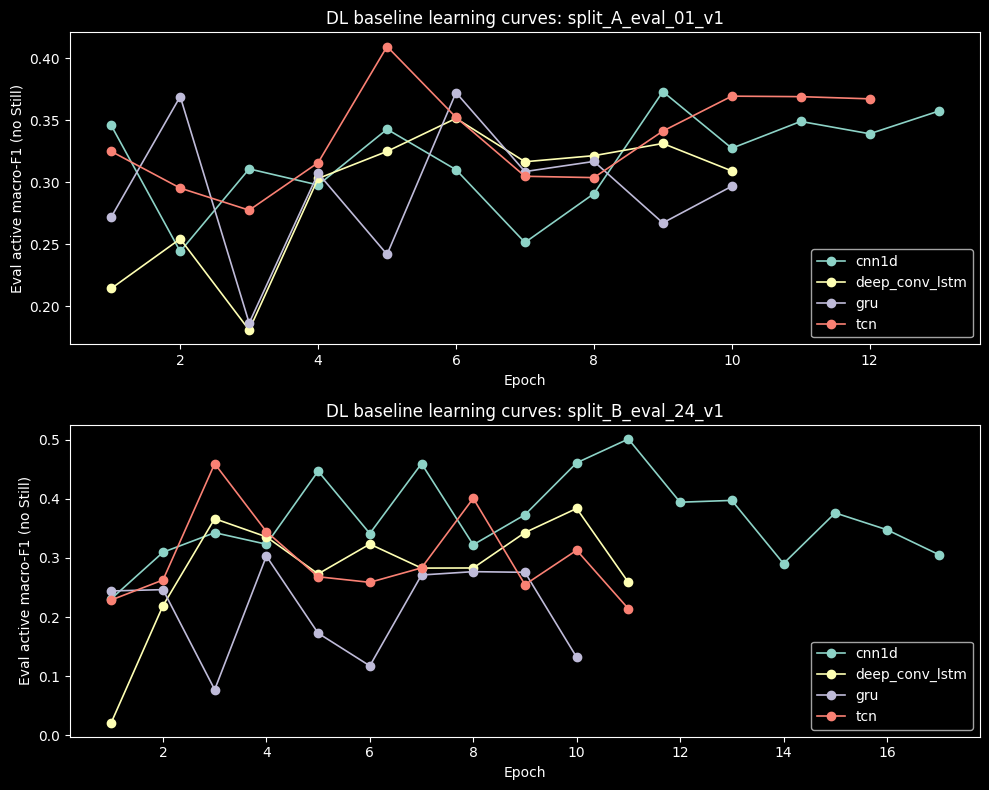

In [14]:
fig, axes = plt.subplots(len(splits), 1, figsize=(10, 4 * len(splits)), sharex=False)
if len(splits) == 1:
    axes = np.array([axes])
axes = np.asarray(axes).reshape(-1)

for ax, (split_name, split_history) in zip(axes, history_df.groupby("split_config")):
    for model_name, history in split_history.groupby("model"):
        ax.plot(history["epoch"], history["eval_active_macro_f1_no_still"], marker="o", linewidth=1.2, label=model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Eval active macro-F1 (no Still)")
    ax.set_title(f"DL baseline learning curves: {split_name}")
    ax.legend()
fig.tight_layout()
plt.show()


In [15]:
for split_name, split_reports in reports.items():
    for model_name, report_text in split_reports.items():
        print(f"=== {split_name} / {model_name} / eval ===")
        print(report_text)

display(eval_prediction_tables["split_A_eval_01_v1"]["cnn1d"].head(20))


=== split_A_eval_01_v1 / cnn1d / eval ===
              precision    recall  f1-score   support

       Still       0.74      0.64      0.69       634
     Gesture       0.31      0.20      0.24       163
     Nodding       0.15      0.32      0.20        96
    Drinking       0.16      0.80      0.27         5
    Toasting       0.00      0.00      0.00         2

    accuracy                           0.53       900
   macro avg       0.27      0.39      0.28       900
weighted avg       0.59      0.53      0.55       900

=== split_A_eval_01_v1 / gru / eval ===
              precision    recall  f1-score   support

       Still       0.71      0.25      0.37       634
     Gesture       0.35      0.12      0.18       163
     Nodding       0.10      0.65      0.18        96
    Drinking       0.22      0.80      0.35         5
    Toasting       0.00      0.00      0.00         2

    accuracy                           0.27       900
   macro avg       0.28      0.36      0.21      

,annotation_id,start_time,end_time,purity,y_true,y_pred
0,01_v1,2025-07-17 14:02:30.180,2025-07-17 14:02:31.160,0.70,Gesture,Still
1,01_v1,2025-07-17 14:02:31.180,2025-07-17 14:02:32.160,1.00,Gesture,Gesture
2,01_v1,2025-07-17 14:02:32.180,2025-07-17 14:02:33.160,1.00,Gesture,Gesture
3,01_v1,2025-07-17 14:02:33.180,2025-07-17 14:02:34.160,1.00,Gesture,Still
4,01_v1,2025-07-17 14:02:34.180,2025-07-17 14:02:35.160,1.00,Gesture,Nodding
5,01_v1,2025-07-17 14:02:35.180,2025-07-17 14:02:36.160,1.00,Gesture,Still
6,01_v1,2025-07-17 14:02:36.180,2025-07-17 14:02:37.160,1.00,Gesture,Still
7,01_v1,2025-07-17 14:02:37.180,2025-07-17 14:02:38.160,0.68,Still,Still
8,01_v1,2025-07-17 14:02:38.180,2025-07-17 14:02:39.160,1.00,Still,Gesture
9,01_v1,2025-07-17 14:02:39.180,2025-07-17 14:02:40.160,0.92,Gesture,Nodding


In [16]:
LABEL_COLORS = {
    "Still": "#d9d9d9",
    "Gesture": "#f4a261",
    "Drinking": "#2a9d8f",
    "Toasting": "#577590",
    "Nodding": "#b56576",
}


def build_sample_runs(frame: pd.DataFrame, time_col: str, label_col: str, origin: pd.Timestamp):
    frame = frame[[time_col, label_col]].sort_values(time_col).reset_index(drop=True)
    runs = []
    if frame.empty:
        return runs
    start_idx = 0
    for i in range(1, len(frame) + 1):
        if i == len(frame) or frame.loc[i, label_col] != frame.loc[i - 1, label_col]:
            runs.append(((frame.loc[start_idx, time_col] - origin).total_seconds(), (frame.loc[i - 1, time_col] - origin).total_seconds(), frame.loc[i - 1, label_col]))
            start_idx = i
    return runs


def build_interval_runs(frame: pd.DataFrame, start_col: str, end_col: str, label_col: str, origin: pd.Timestamp):
    frame = frame[[start_col, end_col, label_col]].sort_values(start_col).reset_index(drop=True)
    runs = []
    if frame.empty:
        return runs
    gap_tolerance = pd.Timedelta(milliseconds=25)
    current_start = frame.loc[0, start_col]
    current_end = frame.loc[0, end_col]
    current_label = frame.loc[0, label_col]
    for i in range(1, len(frame)):
        row = frame.loc[i]
        if row[label_col] == current_label and row[start_col] <= current_end + gap_tolerance:
            current_end = max(current_end, row[end_col])
        else:
            runs.append(((current_start - origin).total_seconds(), (current_end - origin).total_seconds(), current_label))
            current_start = row[start_col]
            current_end = row[end_col]
            current_label = row[label_col]
    runs.append(((current_start - origin).total_seconds(), (current_end - origin).total_seconds(), current_label))
    return runs


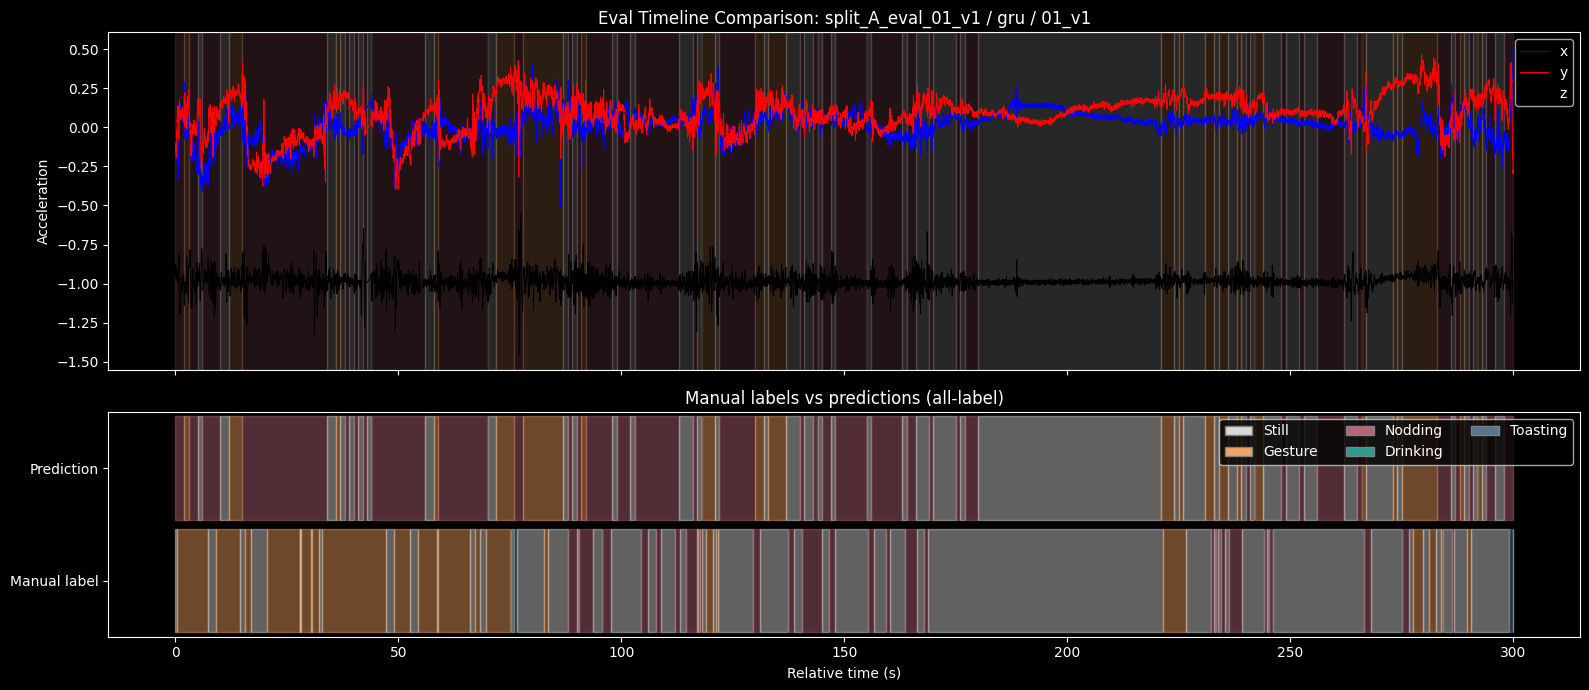

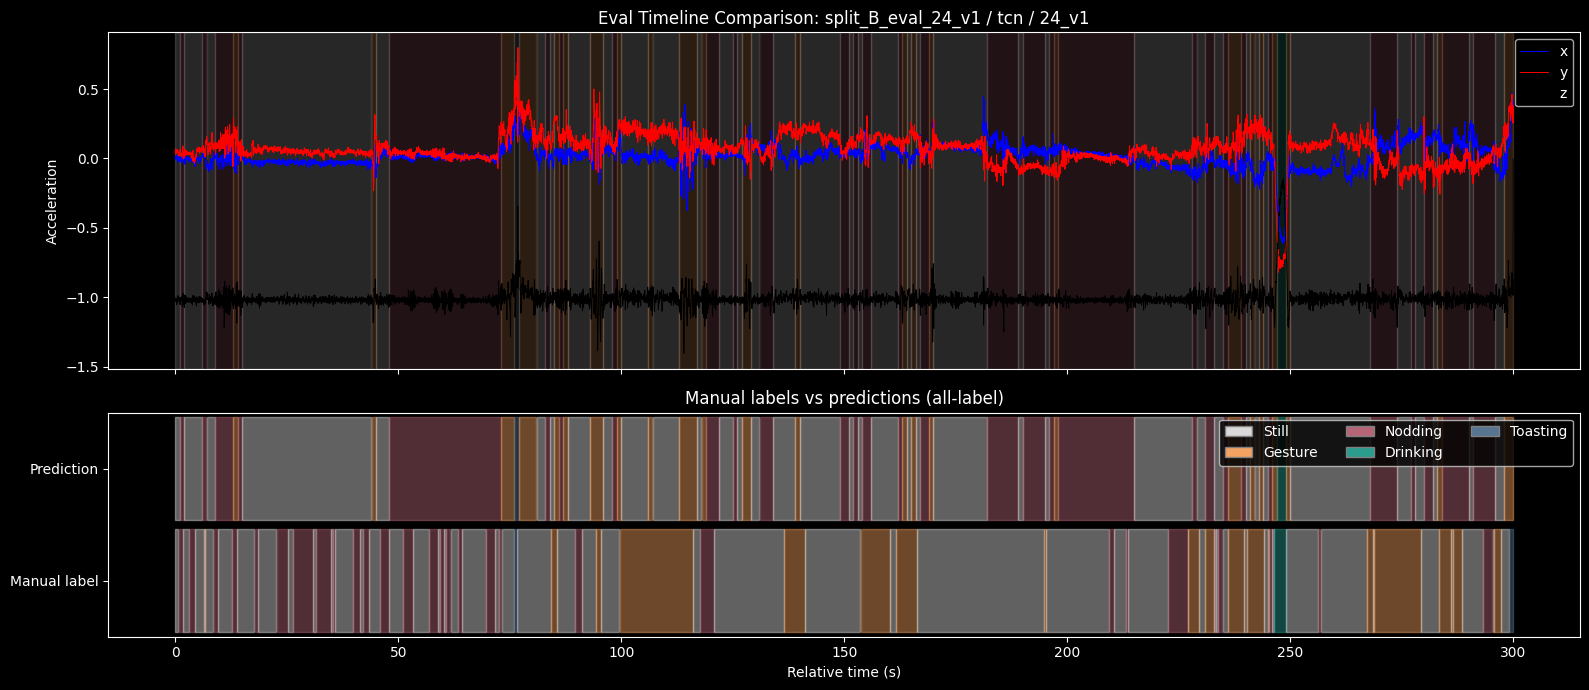

In [17]:
plot_task_name = "active-only" if DROP_STILL_WINDOWS else "all-label"
for split_name in splits:
    eval_rows = results_df[(results_df["split_config"] == split_name) & (results_df["split"] == "eval")]
    top_model = eval_rows.sort_values("active_macro_f1_no_still", ascending=False).iloc[0]["model"]
    eval_plot_df = eval_prediction_tables[split_name][top_model]
    toast_counts = eval_plot_df.loc[eval_plot_df["y_true"] == "Toasting", "annotation_id"].value_counts()
    plot_annotation_id = toast_counts.idxmax() if not toast_counts.empty else eval_plot_df["annotation_id"].value_counts().idxmax()
    eval_plot_df = eval_plot_df[eval_plot_df["annotation_id"] == plot_annotation_id].reset_index(drop=True)

    plot_start = eval_plot_df["start_time"].iloc[0]
    plot_end = eval_plot_df["end_time"].iloc[-1]
    plot_origin = plot_start

    acc_plot = df[
        (df["annotation_id"] == plot_annotation_id)
        & (df["time"] >= plot_start)
        & (df["time"] <= plot_end)
    ].copy().reset_index(drop=True)
    acc_plot["time_rel_s"] = (acc_plot["time"] - plot_origin).dt.total_seconds()

    manual_runs = build_sample_runs(acc_plot, "time", TARGET_COLUMN, plot_origin)
    predicted_runs = build_interval_runs(eval_plot_df, "start_time", "end_time", "y_pred", plot_origin)

    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
    ax0, ax1 = axes

    for start_time, end_time, predicted_label in predicted_runs:
        ax0.axvspan(start_time, end_time, color=LABEL_COLORS.get(str(predicted_label), "#cccccc"), alpha=0.18)

    ax0.plot(acc_plot["time_rel_s"], acc_plot["x"], label="x", color="blue", linewidth=0.7)
    ax0.plot(acc_plot["time_rel_s"], acc_plot["y"], label="y", color="red", linewidth=0.7)
    ax0.plot(acc_plot["time_rel_s"], acc_plot["z"], label="z", color="black", linewidth=0.7)
    ax0.set_title(f"Eval Timeline Comparison: {split_name} / {top_model} / {plot_annotation_id}")
    ax0.set_ylabel("Acceleration")
    ax0.legend(loc="upper right")

    for start_time, end_time, predicted_label in predicted_runs:
        ax1.axvspan(start_time, end_time, ymin=0.52, ymax=0.98, color=LABEL_COLORS.get(str(predicted_label), "#cccccc"), alpha=0.45)
    for start_time, end_time, manual_label in manual_runs:
        ax1.axvspan(start_time, end_time, ymin=0.02, ymax=0.48, color=LABEL_COLORS.get(str(manual_label), "#cccccc"), alpha=0.45)

    ax1.set_ylim(0, 1)
    ax1.set_yticks([0.25, 0.75])
    ax1.set_yticklabels(["Manual label", "Prediction"])
    ax1.set_title(f"Manual labels vs predictions ({plot_task_name})")
    ax1.set_xlabel("Relative time (s)")

    legend_handles = [Patch(facecolor=LABEL_COLORS[label], edgecolor="gray", label=label) for label in label_order]
    ax1.legend(handles=legend_handles, loc="upper right", ncol=min(3, max(1, len(legend_handles))))

    fig.tight_layout()
    plt.show()


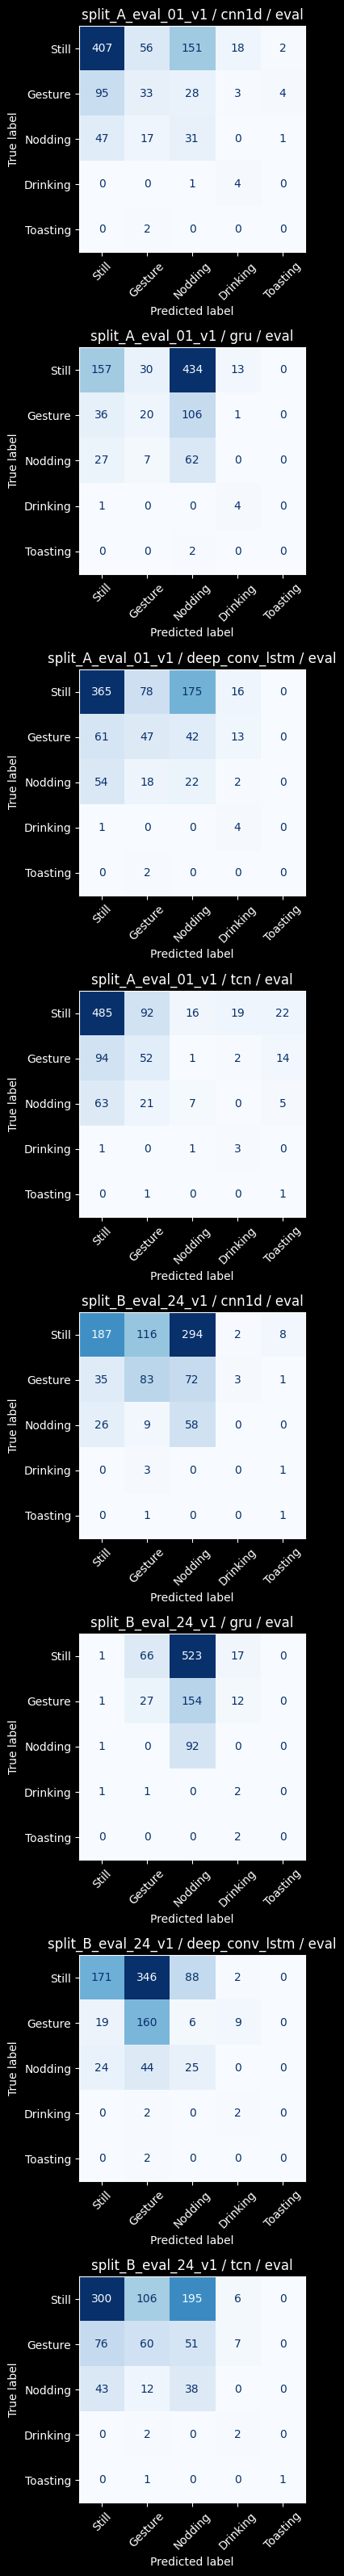

In [18]:
n_rows = len(splits) * len(model_builders)
fig, axes = plt.subplots(n_rows, 1, figsize=(6, 4 * n_rows))
if n_rows == 1:
    axes = np.array([axes])
axes = np.asarray(axes).reshape(-1)

row_idx = 0
for split_name, split_data in splits.items():
    y_eval_encoded = split_data["y_eval_encoded"]
    for model_name in model_builders:
        ConfusionMatrixDisplay.from_predictions(
            y_eval_encoded,
            predictions[split_name][model_name]["eval_encoded"],
            labels=label_order_encoded,
            display_labels=label_order,
            xticks_rotation=45,
            colorbar=False,
            cmap="Blues",
            ax=axes[row_idx],
        )
        axes[row_idx].set_title(f"{split_name} / {model_name} / eval")
        row_idx += 1

fig.tight_layout()
plt.show()


In [19]:
eval_results = results_df[results_df["split"] == "eval"].sort_values("active_macro_f1_no_still", ascending=False)
display(eval_results)

print("Quick performance read:")
for _, row in eval_results.iterrows():
    print(
        f"- {row['split_config']} / {row['model']}: eval acc={row['accuracy']:.3f}, "
        f"active acc={row['active_accuracy']:.3f}, active macro-F1(no Still)={row['active_macro_f1_no_still']:.3f}"
    )


,split_config,model,split,accuracy,macro_precision,macro_recall,macro_f1,active_accuracy,active_macro_precision_no_still,active_macro_recall_no_still,active_macro_f1_no_still,n_samples,active_n_samples
15,split_B_eval_24_v1,tcn,eval,0.445556,0.462924,0.442423,0.396716,0.344710,0.612297,0.429470,0.459510,900,293
9,split_B_eval_24_v1,cnn1d,eval,0.365556,0.274649,0.371913,0.244902,0.484642,0.411018,0.387873,0.373148,900,293
3,split_A_eval_01_v1,gru,eval,0.270000,0.277231,0.363233,0.214808,0.323308,0.476362,0.392133,0.369173,900,266
13,split_B_eval_24_v1,deep_conv_lstm,eval,0.397778,0.290361,0.375055,0.263103,0.638225,0.439375,0.398390,0.366478,900,293
1,split_A_eval_01_v1,cnn1d,eval,0.527778,0.270765,0.393465,0.280049,0.255639,0.430678,0.331343,0.342770,900,266
7,split_A_eval_01_v1,tcn,eval,0.608889,0.299268,0.451384,0.288751,0.236842,0.532620,0.372984,0.315765,900,266
5,split_A_eval_01_v1,deep_conv_lstm,eval,0.486667,0.257862,0.378644,0.258249,0.274436,0.313942,0.329378,0.254257,900,266
11,split_B_eval_24_v1,gru,eval,0.135556,0.143495,0.326014,0.102468,0.412969,0.365817,0.407106,0.246504,900,293


Quick performance read:
- split_B_eval_24_v1 / tcn: eval acc=0.446, active acc=0.345, active macro-F1(no Still)=0.460
- split_B_eval_24_v1 / cnn1d: eval acc=0.366, active acc=0.485, active macro-F1(no Still)=0.373
- split_A_eval_01_v1 / gru: eval acc=0.270, active acc=0.323, active macro-F1(no Still)=0.369
- split_B_eval_24_v1 / deep_conv_lstm: eval acc=0.398, active acc=0.638, active macro-F1(no Still)=0.366
- split_A_eval_01_v1 / cnn1d: eval acc=0.528, active acc=0.256, active macro-F1(no Still)=0.343
- split_A_eval_01_v1 / tcn: eval acc=0.609, active acc=0.237, active macro-F1(no Still)=0.316
- split_A_eval_01_v1 / deep_conv_lstm: eval acc=0.487, active acc=0.274, active macro-F1(no Still)=0.254
- split_B_eval_24_v1 / gru: eval acc=0.136, active acc=0.413, active macro-F1(no Still)=0.247
